# TabICL validation trajectory

This notebook analyses the validation results from the 500-epoch
Gaussian, Dropout and Stochastic LayerNorm runs.

The underlying model evaluation was performed on 4,096 deterministic
validation tasks with 64 predictive samples per target.

This notebook does not recompute model predictions. It reads the
machine-readable outputs produced by `evaluate_synthetic_1d.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


ROOT = Path("/scratch2/ij292/tnp-crps")

RESULT_DIR = (
    ROOT
    / "results"
    / "tabular"
    / "tabicl_nc128_500_val_milestones_v2"
)

METRICS_PATH = RESULT_DIR / "metrics.csv"
RESOLVED_CONFIG_PATH = RESULT_DIR / "eval_config_resolved.json"

OUTPUT_DIR = RESULT_DIR / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOCKED_VALIDATION_ESCAPE_CRPS_M8 = 0.479957606876269

if not METRICS_PATH.is_file():
    raise FileNotFoundError(METRICS_PATH)

print("Metrics:", METRICS_PATH)
print("Outputs:", OUTPUT_DIR)

Metrics: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_val_milestones_v2/metrics.csv
Outputs: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_val_milestones_v2/notebook_outputs


In [2]:
metrics = pd.read_csv(METRICS_PATH)

trajectory = metrics[
    (metrics["region"] == "all")
    & (metrics["context_bucket"] == "all")
].copy()

parsed_names = trajectory["model_name"].str.extract(
    r"^(gaussian|dropout|stochln)_500run_e(\d+)$"
)

if parsed_names.isna().any().any():
    unmatched = trajectory.loc[
        parsed_names.isna().any(axis=1),
        "model_name",
    ].tolist()

    raise ValueError(
        f"Could not parse model names: {unmatched}"
    )

trajectory["family"] = parsed_names[0]
trajectory["epoch"] = parsed_names[1].astype(int)

trajectory = trajectory.sort_values(
    ["family", "epoch"]
).reset_index(drop=True)

expected_families = {
    "gaussian",
    "dropout",
    "stochln",
}

expected_epochs = {
    75,
    100,
    250,
    500,
}

assert set(trajectory["family"]) == expected_families
assert set(trajectory["epoch"]) == expected_epochs
assert len(trajectory) == 12

trajectory

,model_name,training_alpha,metric_alpha,eval_set,region,context_bucket,num_eval_samples,numel,rmse_pooled,crps,...,rank_057_prob,rank_058_prob,rank_059_prob,rank_060_prob,rank_061_prob,rank_062_prob,rank_063_prob,rank_064_prob,family,epoch
0,dropout_500run_e075,1.0,1.0,tabicl_nc128_val,all,all,64,524288,0.915950,0.301847,...,0.015982,0.016098,0.015928,0.015965,0.016106,0.016148,0.016697,0.017181,dropout,75
1,dropout_500run_e100,1.0,1.0,tabicl_nc128_val,all,all,64,524288,0.911859,0.298756,...,0.015659,0.015305,0.015348,0.015167,0.015001,0.015043,0.015293,0.019993,dropout,100
2,dropout_500run_e250,1.0,1.0,tabicl_nc128_val,all,all,64,524288,0.899806,0.289127,...,0.014893,0.014454,0.014355,0.014380,0.014292,0.014580,0.014408,0.015333,dropout,250
3,dropout_500run_e500,1.0,1.0,tabicl_nc128_val,all,all,64,524288,0.890958,0.280511,...,0.011354,0.011240,0.011051,0.010664,0.010889,0.010757,0.010645,0.011293,dropout,500
4,gaussian_500run_e075,NaN,1.0,tabicl_nc128_val,all,all,64,524288,0.953755,0.368106,...,0.010014,0.009455,0.008932,0.008535,0.008034,0.007732,0.007442,0.010500,gaussian,75
5,gaussian_500run_e100,NaN,1.0,tabicl_nc128_val,all,all,64,524288,0.944898,0.353455,...,0.010170,0.009689,0.009462,0.009201,0.008898,0.008831,0.009361,0.014616,gaussian,100
6,gaussian_500run_e250,NaN,1.0,tabicl_nc128_val,all,all,64,524288,0.928691,0.335777,...,0.012318,0.012302,0.012421,0.012306,0.012590,0.013021,0.015089,0.029089,gaussian,250
7,gaussian_500run_e500,NaN,1.0,tabicl_nc128_val,all,all,64,524288,0.913769,0.324844,...,0.010185,0.009766,0.009481,0.009344,0.009018,0.008768,0.009047,0.014946,gaussian,500
8,stochln_500run_e075,1.0,1.0,tabicl_nc128_val,all,all,64,524288,0.930880,0.317854,...,0.011526,0.011377,0.011297,0.010780,0.011061,0.010626,0.010838,0.013445,stochln,75
9,stochln_500run_e100,1.0,1.0,tabicl_nc128_val,all,all,64,524288,0.925668,0.313400,...,0.012722,0.012970,0.012201,0.012161,0.011883,0.011810,0.011988,0.013279,stochln,100


In [3]:
trajectory_columns = [
    "family",
    "epoch",
    "rmse_pooled",
    "crps",
    "energy_score",
    "ensemble_spread",
    "spread_skill_ratio",
    "coverage_90",
    "width_90",
]

trajectory_table = trajectory[
    trajectory_columns
].copy()

display(
    trajectory_table.style.format(
        {
            "rmse_pooled": "{:.6f}",
            "crps": "{:.6f}",
            "energy_score": "{:.6f}",
            "ensemble_spread": "{:.6f}",
            "spread_skill_ratio": "{:.6f}",
            "coverage_90": "{:.6f}",
            "width_90": "{:.6f}",
        }
    )
)

trajectory_table.to_csv(
    OUTPUT_DIR / "validation_trajectory.csv",
    index=False,
)

# latex = trajectory_table.to_latex(
#     index=False,
#     float_format=lambda value: f"{value:.6f}",
# )

# (
#     OUTPUT_DIR / "validation_trajectory.tex"
# ).write_text(
#     latex,
#     encoding="utf-8",
# )

print(
    "Wrote:",
    OUTPUT_DIR / "validation_trajectory.csv",
)
# print(
#     "Wrote:",
#     OUTPUT_DIR / "validation_trajectory.tex",
# )

,family,epoch,rmse_pooled,crps,energy_score,ensemble_spread,spread_skill_ratio,coverage_90,width_90
0,dropout,75,0.915950,0.301847,5.978759,0.835982,0.919797,0.895866,1.611629
1,dropout,100,0.911859,0.298756,5.963279,0.689800,0.762364,0.871857,1.469690
2,dropout,250,0.899806,0.289127,5.786686,0.752611,0.842924,0.890142,1.499220
3,dropout,500,0.890958,0.280511,5.641573,0.803110,0.908416,0.911560,1.541450
4,gaussian,75,0.953755,0.368106,6.551319,0.991625,1.047797,0.932720,2.492929
5,gaussian,100,0.944898,0.353455,6.397298,0.849961,0.906526,0.908484,2.167828
6,gaussian,250,0.928691,0.335777,6.154483,0.843025,0.914821,0.892954,2.067183
7,gaussian,500,0.913769,0.324844,5.978384,0.873740,0.963635,0.916529,2.053729
8,stochln,75,0.930880,0.317854,6.552513,0.765056,0.828258,0.911396,1.749253
9,stochln,100,0.925668,0.313400,6.449600,0.789872,0.859940,0.904024,1.724319


Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_val_milestones_v2/notebook_outputs/validation_trajectory.csv


In [4]:
crps_by_epoch = trajectory.pivot(
    index="family",
    columns="epoch",
    values="crps",
)

required_epochs = {
    100,
    500,
}

if not required_epochs.issubset(
    set(crps_by_epoch.columns)
):
    raise ValueError(
        "Both epoch 100 and epoch 500 are required."
    )

comparison = pd.DataFrame(
    {
        "crps_epoch_100": crps_by_epoch[100],
        "crps_epoch_500": crps_by_epoch[500],
    }
)

comparison["absolute_change"] = (
    comparison["crps_epoch_500"]
    - comparison["crps_epoch_100"]
)

comparison["relative_change_pct"] = (
    100.0
    * comparison["absolute_change"]
    / comparison["crps_epoch_100"]
)

comparison["point_trigger_gt_1pct_worse"] = (
    comparison["relative_change_pct"] > 1.0
)

comparison = comparison.loc[
    ["gaussian", "dropout", "stochln"]
]

display(
    comparison.style.format(
        {
            "crps_epoch_100": "{:.6f}",
            "crps_epoch_500": "{:.6f}",
            "absolute_change": "{:.6f}",
            "relative_change_pct": "{:.3f}%",
        }
    )
)

comparison.to_csv(
    OUTPUT_DIR / "epoch100_vs_epoch500.csv"
)

common_headline_epoch = (
    100
    if comparison[
        "point_trigger_gt_1pct_worse"
    ].any()
    else 500
)

print(
    "Common headline checkpoint:",
    f"epoch {common_headline_epoch}",
)

,crps_epoch_100,crps_epoch_500,absolute_change,relative_change_pct,point_trigger_gt_1pct_worse
family,,,,,
gaussian,0.353455,0.324844,-0.028612,-8.095%,False
dropout,0.298756,0.280511,-0.018245,-6.107%,False
stochln,0.313400,0.296958,-0.016442,-5.246%,False


Common headline checkpoint: epoch 500


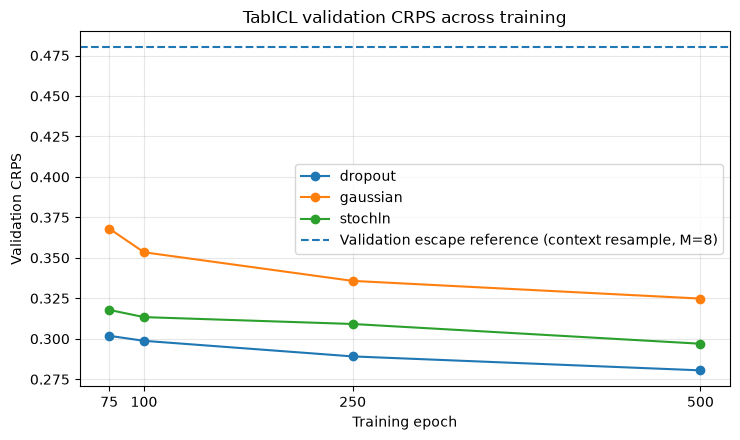

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_val_milestones_v2/notebook_outputs/validation_crps_trajectory.png


In [5]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

for family, family_rows in trajectory.groupby(
    "family",
    sort=True,
):
    ax.plot(
        family_rows["epoch"],
        family_rows["crps"],
        marker="o",
        label=family,
    )

ax.axhline(
    LOCKED_VALIDATION_ESCAPE_CRPS_M8,
    linestyle="--",
    label=(
        "Validation escape reference "
        "(context resample, M=8)"
    ),
)

ax.set_xlabel("Training epoch")
ax.set_ylabel("Validation CRPS")
ax.set_title(
    "TabICL validation CRPS across training"
)
ax.set_xticks(
    sorted(trajectory["epoch"].unique())
)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "validation_crps_trajectory.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", figure_path)

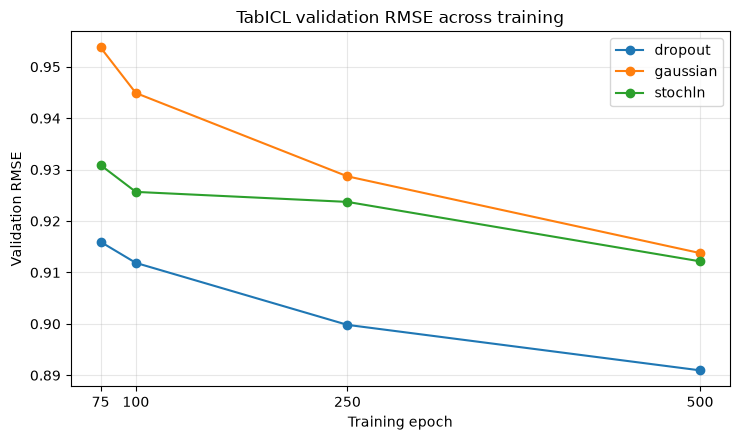

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_val_milestones_v2/notebook_outputs/validation_rmse_trajectory.png


In [6]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

for family, family_rows in trajectory.groupby(
    "family",
    sort=True,
):
    ax.plot(
        family_rows["epoch"],
        family_rows["rmse_pooled"],
        marker="o",
        label=family,
    )

ax.set_xlabel("Training epoch")
ax.set_ylabel("Validation RMSE")
ax.set_title(
    "TabICL validation RMSE across training"
)
ax.set_xticks(
    sorted(trajectory["epoch"].unique())
)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "validation_rmse_trajectory.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", figure_path)

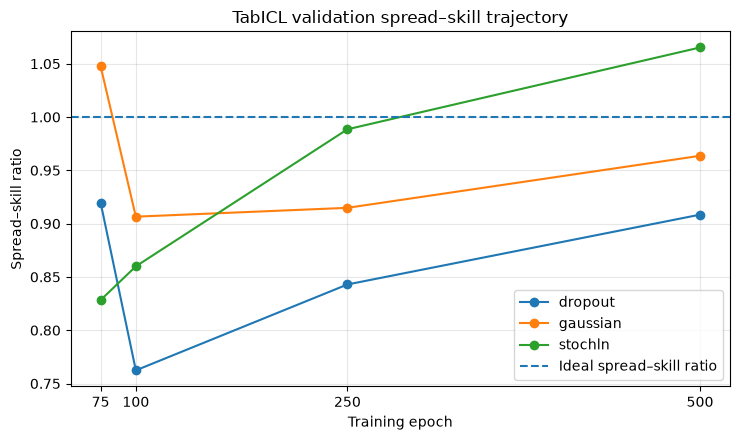

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_val_milestones_v2/notebook_outputs/validation_spread_skill_trajectory.png


In [7]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

for family, family_rows in trajectory.groupby(
    "family",
    sort=True,
):
    ax.plot(
        family_rows["epoch"],
        family_rows["spread_skill_ratio"],
        marker="o",
        label=family,
    )

ax.axhline(
    1.0,
    linestyle="--",
    label="Ideal spread–skill ratio",
)

ax.set_xlabel("Training epoch")
ax.set_ylabel("Spread–skill ratio")
ax.set_title(
    "TabICL validation spread–skill trajectory"
)
ax.set_xticks(
    sorted(trajectory["epoch"].unique())
)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "validation_spread_skill_trajectory.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", figure_path)

In [8]:
epoch_500 = (
    trajectory[
        trajectory["epoch"] == 500
    ]
    .sort_values("crps")
    [
        [
            "family",
            "rmse_pooled",
            "crps",
            "energy_score",
            "ensemble_spread",
            "spread_skill_ratio",
            "coverage_90",
            "width_90",
        ]
    ]
    .reset_index(drop=True)
)

display(
    epoch_500.style.format(
        {
            "rmse_pooled": "{:.6f}",
            "crps": "{:.6f}",
            "energy_score": "{:.6f}",
            "ensemble_spread": "{:.6f}",
            "spread_skill_ratio": "{:.6f}",
            "coverage_90": "{:.6f}",
            "width_90": "{:.6f}",
        }
    )
)

epoch_500.to_csv(
    OUTPUT_DIR / "epoch500_validation_ranking.csv",
    index=False,
)

best = epoch_500.iloc[0]

print(
    "Best epoch-500 validation CRPS:",
    best["family"],
    float(best["crps"]),
)

,family,rmse_pooled,crps,energy_score,ensemble_spread,spread_skill_ratio,coverage_90,width_90
0,dropout,0.890958,0.280511,5.641573,0.803110,0.908416,0.911560,1.541450
1,stochln,0.912162,0.296958,6.167687,0.964170,1.065242,0.902925,1.655527
2,gaussian,0.913769,0.324844,5.978384,0.873740,0.963635,0.916529,2.053729


Best epoch-500 validation CRPS: dropout 0.2805108423344791


## Interpretation

All three model families improve between epochs 100 and 500.

- Dropout CRPS improves by approximately 6.11%.
- Gaussian CRPS improves by approximately 8.09%.
- Stochastic LayerNorm CRPS improves by approximately 5.25%.

No model is more than 1% worse at epoch 500 than at epoch 100.
Therefore, the symmetric late-overtraining trigger is not activated,
and epoch 500 remains the common headline checkpoint.

The completed standalone 100-epoch runs are a separate training-budget
experiment because their cosine schedule completed at 100,000 updates.
Epoch 100 of the 500-epoch run is only a within-run convergence
milestone and should not be substituted for the standalone pilot.